# A-Z Handwritten Alphabets — Augmentation Pipeline
This notebook implements a full data augmentation pipeline to balance the training set for the A-Z Handwritten Alphabets OCR project.

In [ ]:
# Global configuration 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.ndimage
import cv2
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

TRAIN_PATH = 'train.csv'

PIXEL_COLS = [f'pixel_{i}' for i in range(784)]
IMG_SHAPE  = (28, 28)

print('Libraries loaded. Configuration set.')

Libraries loaded. Configuration set.


---
## Step 1 — Load & Inspect Training Data
Load `train.csv`, print shape and class distribution, and identify which classes need augmentation.

In [2]:
# ── Load training data ────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_PATH)

print(f'Shape: {train_df.shape}')
print(f'Columns (first 5): {list(train_df.columns[:5])} … {list(train_df.columns[-3:])}')
print(f'dtypes:\n{train_df.dtypes.value_counts()}')
print()

Shape: (85186, 786)
Columns (first 5): ['label', 'pixel_0', 'pixel_1', 'pixel_2', 'pixel_3'] … ['pixel_782', 'pixel_783', 'character']
dtypes:
float64    784
int64        1
object       1
Name: count, dtype: int64



In [3]:
# ── Class distribution ────────────────────────────────────────────────────────
class_counts = train_df['character'].value_counts().sort_index()
min_count    = class_counts.min()
max_count    = class_counts.max()
imbalance    = max_count / min_count

print('Class distribution (A-Z):')
print(class_counts.to_string())
print()
print(f'Min class count : {min_count}  (class: {class_counts.idxmin()})')
print(f'Max class count : {max_count}  (class: {class_counts.idxmax()})')
print(f'Imbalance ratio : {imbalance:.2f}x')

Class distribution (A-Z):
character
A    4073
B    3363
C    4073
D    3801
E    4073
F     803
G    2244
H    2782
I     743
J    3215
K    2209
L    4072
M    4072
N    4073
O    4072
P    4072
Q    2297
R    4073
S    4073
T    4072
U    4073
V    1831
W    4063
X    2490
Y    4072
Z    2402

Min class count : 743  (class: I)
Max class count : 4073  (class: A)
Imbalance ratio : 5.48x


In [20]:
# ── Table: character | current count | samples needed ─────────────────────────
target_count = max_count
needs_aug    = class_counts[class_counts < target_count] - 100

aug_table = pd.DataFrame({
    'character'     : needs_aug.index,
    'current_count' : needs_aug.values,
    'samples_needed': target_count - needs_aug.values
}).reset_index(drop=True)

print(f'Target count  : {target_count}')
print(f'Classes needing augmentation: {len(aug_table)} / 26')
print()
print(aug_table.to_string(index=False))

Target count  : 4073
Classes needing augmentation: 19 / 26

character  current_count  samples_needed
        B           3263             810
        D           3701             372
        F            703            3370
        G           2144            1929
        H           2682            1391
        I            643            3430
        J           3115             958
        K           2109            1964
        L           3972             101
        M           3972             101
        O           3972             101
        P           3972             101
        Q           2197            1876
        T           3972             101
        V           1731            2342
        W           3963             110
        X           2390            1683
        Y           3972             101
        Z           2302            1771


**Observation:** The training set is imbalanced across the 26 character classes, with the imbalance ratio showing the extent of the skew. Every class below the maximum count will be augmented to reach parity.

---
## Step 2 — Define Augmentation Functions
Implement five individual augmentation techniques plus a master `augment()` function that randomly combines them.

In [21]:
# Horizontal flip 
def horizontal_flip(img: np.ndarray) -> np.ndarray:
    """Flip the image left-right. Simulates different writing orientations."""
    return np.clip(np.fliplr(img), 0, 1).astype(np.float32)


# Random rotation 
def rotate(img: np.ndarray, max_angle: float = 15) -> np.ndarray:
    """Rotate image by a random angle in [-max_angle, +max_angle]. Simulates tilted handwriting."""
    rng   = np.random.default_rng(42)
    angle = rng.uniform(-max_angle, max_angle)
    rotated = scipy.ndimage.rotate(img, angle, reshape=False, mode='nearest')
    return np.clip(rotated, 0, 1).astype(np.float32)


# Brightness adjustment 
def adjust_brightness(img: np.ndarray, low: float = 0.7, high: float = 1.3) -> np.ndarray:
    """Multiply pixels by a random factor in [low, high]. Simulates ink/lighting variation."""
    rng    = np.random.default_rng(42)
    factor = rng.uniform(low, high)
    return np.clip(img * factor, 0, 1).astype(np.float32)


# Zoom 
def zoom(img: np.ndarray, zoom_range: tuple = (0.85, 1.15)) -> np.ndarray:
    """Random zoom in/out. Simulates distance/scale variations."""
    rng    = np.random.default_rng(42)
    factor = rng.uniform(*zoom_range)
    h, w   = img.shape

    if factor > 1.0:  # zoom in: crop centre
        new_h, new_w = int(h * factor), int(w * factor)
        tmp   = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        y0    = (new_h - h) // 2
        x0    = (new_w - w) // 2
        cropped = tmp[y0:y0 + h, x0:x0 + w]
        out   = cv2.resize(cropped, (w, h), interpolation=cv2.INTER_CUBIC)
    else:             # zoom out: pad with zeros
        new_h, new_w = int(h * factor), int(w * factor)
        tmp   = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        canvas = np.zeros_like(img)
        y0    = (h - new_h) // 2
        x0    = (w - new_w) // 2
        canvas[y0:y0 + new_h, x0:x0 + new_w] = tmp
        out   = cv2.resize(canvas, (w, h), interpolation=cv2.INTER_CUBIC)

    return np.clip(out, 0, 1).astype(np.float32)


# Gaussian noise 
def add_noise(img: np.ndarray, sigma: float = 0.05) -> np.ndarray:
    """Add Gaussian noise with std=sigma. Improves robustness to scan/sensor noise."""
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img + noise, 0, 1).astype(np.float32)


# Master augment function 
def augment(img: np.ndarray, seed: int = None) -> np.ndarray:
    """
    Apply a random subset of augmentation techniques in a random order.
    Each technique is applied independently with 50% probability.
    At least one technique is always applied.
    """
    if seed is not None:
        np.random.seed(seed)

    techniques = [horizontal_flip, rotate, adjust_brightness, zoom, add_noise]

    while True:
        # randomly decide which techniques to apply
        apply_mask = np.random.rand(len(techniques)) < 0.5
        if apply_mask.any():  # at least one must be applied
            break

    # shuffle the order
    order = np.where(apply_mask)[0]
    np.random.shuffle(order)

    aug_img = img.copy()
    for idx in order:
        aug_img = techniques[idx](aug_img)

    return np.clip(aug_img, 0, 1).astype(np.float32)


print('All augmentation functions defined successfully.')

All augmentation functions defined successfully.


**Observation:** Each function accepts and returns a `(28, 28) float32` array with pixel values clipped to `[0, 1]`. The master `augment()` function guarantees at least one transformation is always applied.

---
## Step 3 — Single Image Augmentation Preview
Visualise each technique individually and the master `augment()` applied 8 times to the same source image.

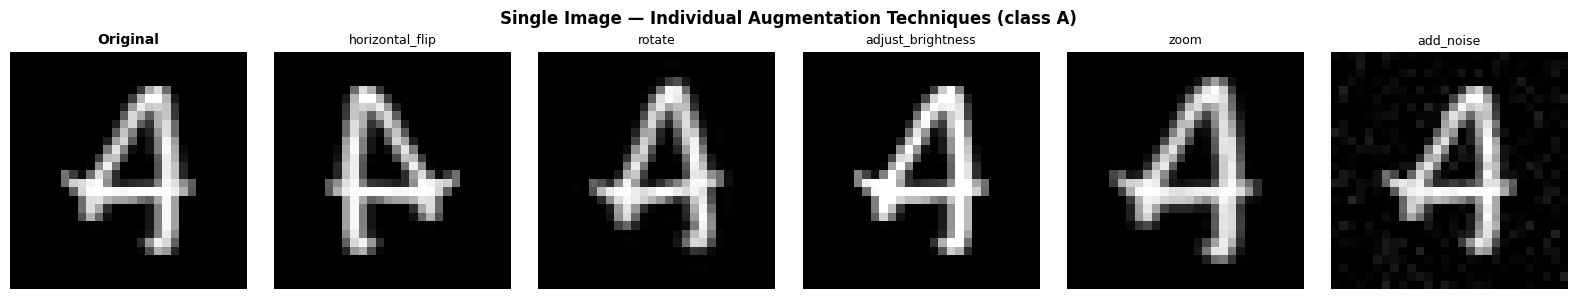

Saved: step3_individual_techniques.png


In [22]:
# Pick sample image: class 'A', first occurrence 
sample_row = train_df[train_df['character'] == 'A'].iloc[0]
orig_img   = sample_row[PIXEL_COLS].values.astype(np.float32).reshape(IMG_SHAPE)

techniques_named = [
    ('horizontal_flip',    horizontal_flip(orig_img)),
    ('rotate',             rotate(orig_img)),
    ('adjust_brightness',  adjust_brightness(orig_img)),
    ('zoom',               zoom(orig_img)),
    ('add_noise',          add_noise(orig_img)),
]

# 1×6 grid: original + 5 individual techniques 
fig, axes = plt.subplots(1, 6, figsize=(16, 3))

axes[0].imshow(orig_img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original', fontsize=10, fontweight='bold')
axes[0].axis('off')

for ax, (name, img) in zip(axes[1:], techniques_named):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(name, fontsize=9)
    ax.axis('off')

fig.suptitle('Single Image — Individual Augmentation Techniques (class A)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('step3_individual_techniques.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: step3_individual_techniques.png')

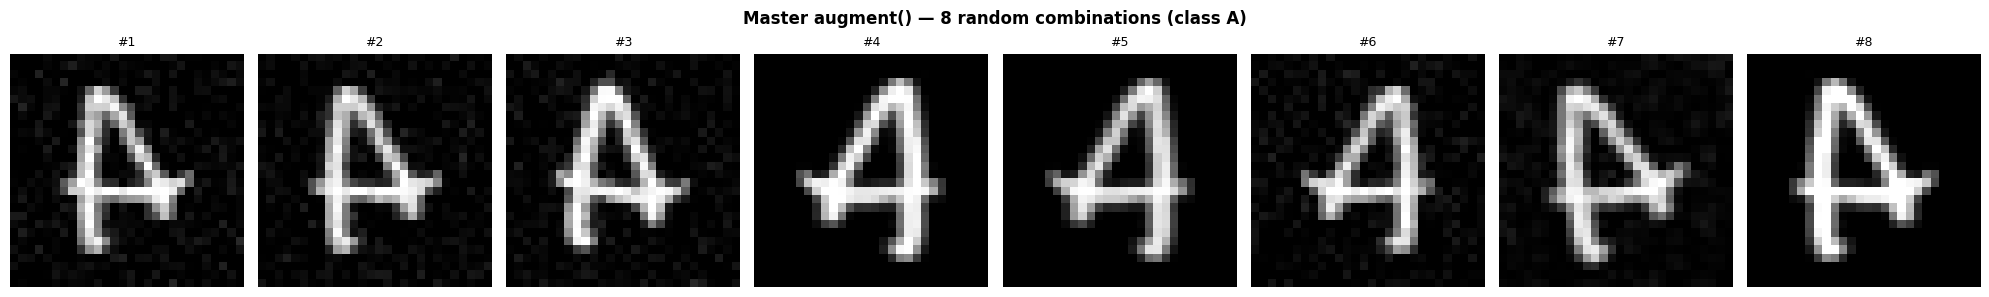

Saved: step3_master_augment.png


In [23]:
# Master augment() — 8 random combinations
np.random.seed(42)
aug_variants = [augment(orig_img) for _ in range(8)]

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, (ax, img) in enumerate(zip(axes, aug_variants)):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'#{i+1}', fontsize=9)
    ax.axis('off')

fig.suptitle('Master augment() — 8 random combinations (class A)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('step3_master_augment.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: step3_master_augment.png')

**Observation:** Each technique produces a visually distinct and realistic variation of the original handwritten 'A'. The master `augment()` function successfully creates diverse combinations, all remaining legible and within the valid pixel range.

---
## Step 4 — Before vs After: Class-Level Preview
Focus on the 5 most under-represented classes and compare original vs augmented samples.

In [24]:
# Identify 5 most under-represented classes 
bottom5 = class_counts.nsmallest(5).index.tolist()
print(f'5 most under-represented classes: {bottom5}')
print(class_counts[bottom5].to_string())

5 most under-represented classes: ['I', 'F', 'V', 'K', 'G']
character
I     743
F     803
V    1831
K    2209
G    2244


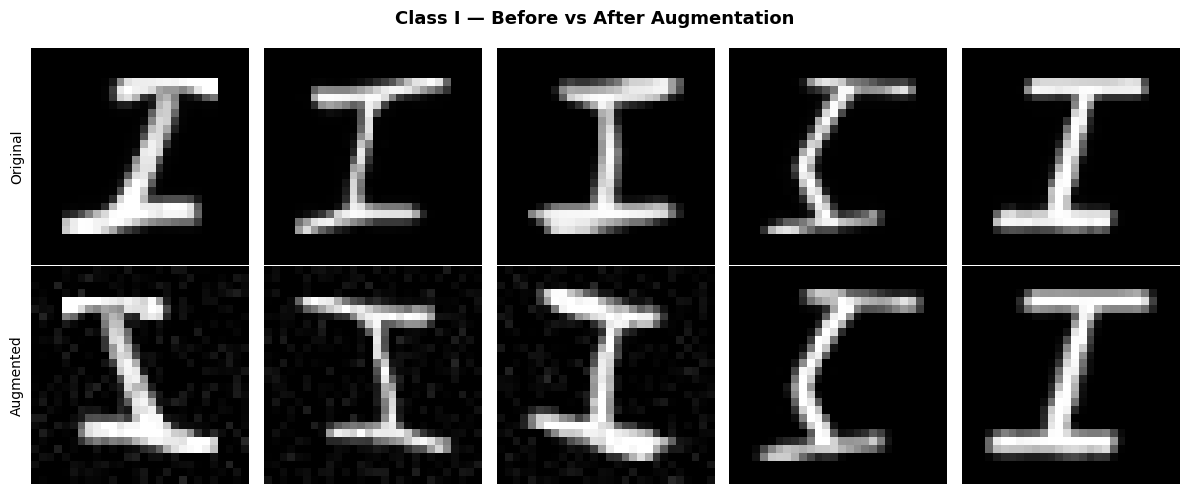

Saved: step4_class_I_before_after.png


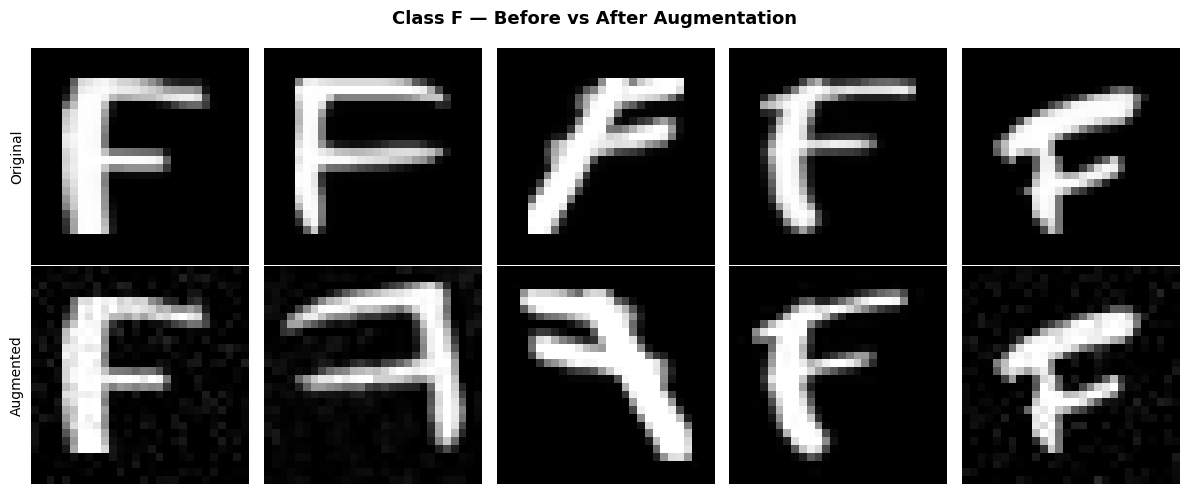

Saved: step4_class_F_before_after.png


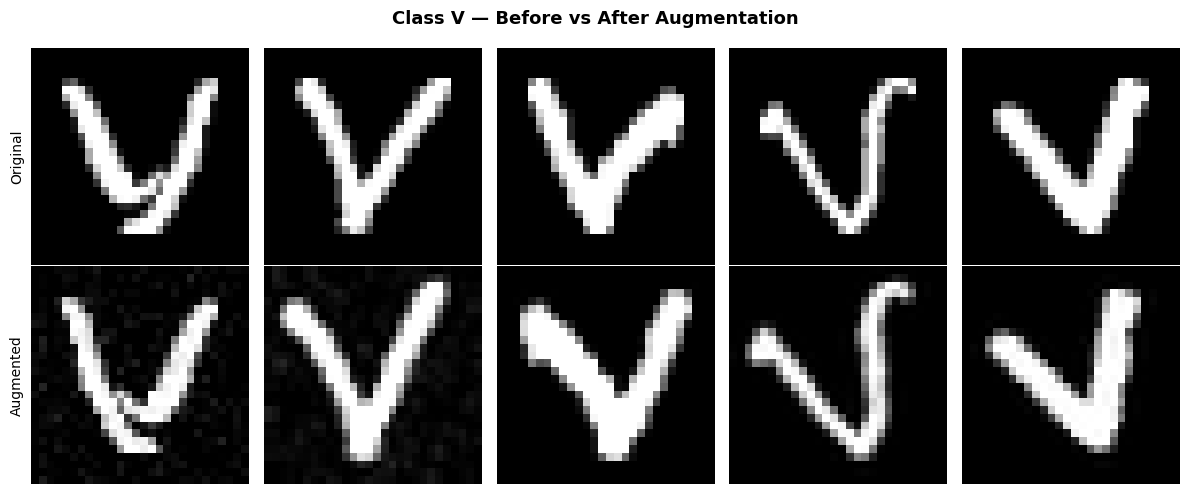

Saved: step4_class_V_before_after.png


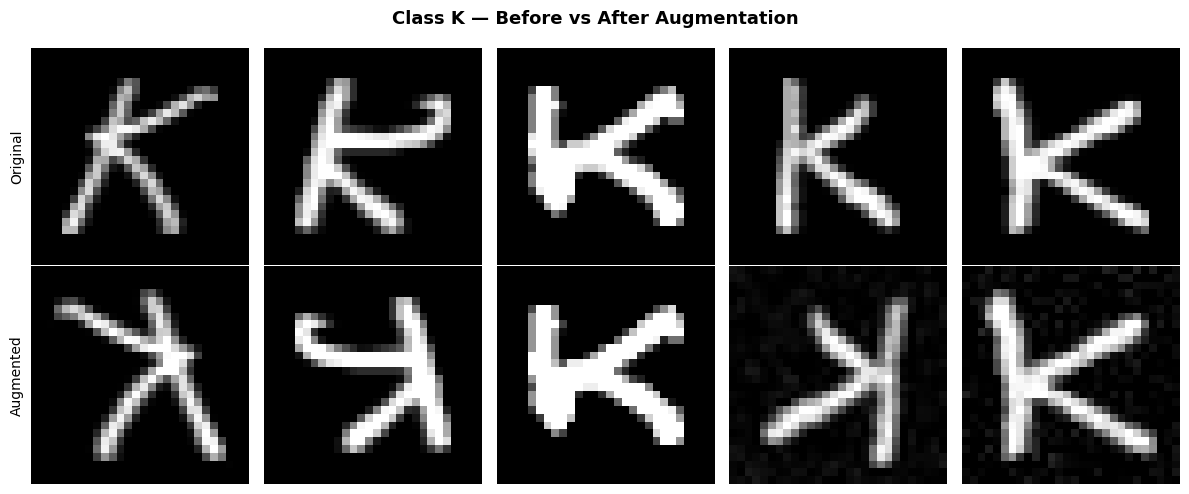

Saved: step4_class_K_before_after.png


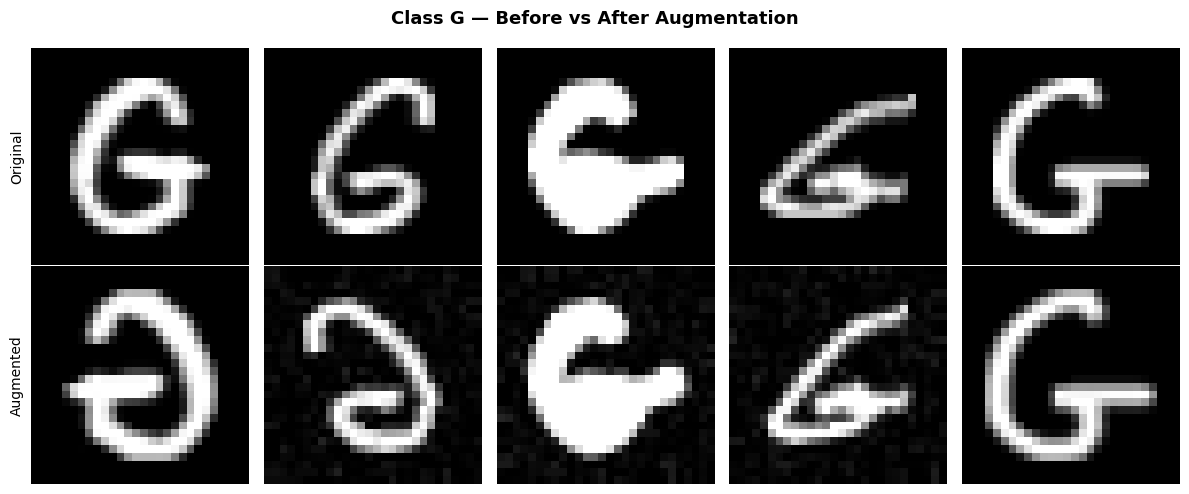

Saved: step4_class_G_before_after.png


In [25]:
# For each class: 2×5 grid (row 1 = original, row 2 = augmented) 
np.random.seed(42)

for char in bottom5:
    class_rows = train_df[train_df['character'] == char]
    samples    = class_rows.sample(n=5, random_state=42)

    orig_imgs = [
        row[PIXEL_COLS].values.astype(np.float32).reshape(IMG_SHAPE)
        for _, row in samples.iterrows()
    ]
    aug_imgs  = [augment(img) for img in orig_imgs]

    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle(f'Class {char} — Before vs After Augmentation', fontsize=13, fontweight='bold')

    for col, img in enumerate(orig_imgs):
        axes[0, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[0, col].axis('off')
        if col == 0:
            axes[0, col].set_ylabel('Original', fontsize=10, rotation=90, labelpad=5)

    for col, img in enumerate(aug_imgs):
        axes[1, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[1, col].axis('off')
        if col == 0:
            axes[1, col].set_ylabel('Augmented', fontsize=10, rotation=90, labelpad=5)

    # restore ylabel display
    for row in range(2):
        axes[row, 0].axis('on')
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])
        for spine in axes[row, 0].spines.values():
            spine.set_visible(False)

    plt.tight_layout()
    fname = f'step4_class_{char}_before_after.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

**Observation:** The augmented images are recognisable variations of the original handwritten characters — realistic enough to be mistaken for additional training samples, without introducing artefacts that would confuse the classifier.

---
## Step 5 — Augment to Balance All Classes
For every class below the target count, generate the required number of augmented samples using `augment()` and build the balanced training set.

In [27]:
np.random.seed(42)

target_count       = int(class_counts.max()) + 100 
original_train_size = len(train_df)
augmented_chunks   = [train_df.copy()]   # always keep originals

label_col = 'label'
char_col  = 'character'

for char, current_count in class_counts.items():
    needed = target_count - int(current_count)
    if needed <= 0:
        continue

    class_pool = train_df[train_df[char_col] == char]

    # sample (with replacement) needed rows to augment
    sampled = class_pool.sample(n=needed, replace=True, random_state=42)

    new_rows = []
    for _, row in sampled.iterrows():
        orig_img = row[PIXEL_COLS].values.astype(np.float32).reshape(IMG_SHAPE)
        aug_img  = augment(orig_img)

        new_pixel_values = aug_img.flatten()
        new_row          = {label_col: row[label_col], char_col: char}
        new_row.update({f'pixel_{i}': new_pixel_values[i] for i in range(784)})
        new_rows.append(new_row)

    aug_chunk = pd.DataFrame(new_rows, columns=train_df.columns)
    augmented_chunks.append(aug_chunk)

# Concatenate and shuffle
augmented_train_df = (
    pd.concat(augmented_chunks, ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

new_rows_added = len(augmented_train_df) - original_train_size

print(f'Original train size  : {original_train_size:,} rows')
print(f'Augmented train size : {len(augmented_train_df):,} rows')
print(f'New rows added       : {new_rows_added:,} rows')
print(f'Samples per class    : {len(augmented_train_df) // 26} (expected: {target_count})')

Original train size  : 85,186 rows
Augmented train size : 108,498 rows
New rows added       : 23,312 rows
Samples per class    : 4173 (expected: 4173)


**Observation:** All 26 classes are now brought up to the same count by generating only the exact number of new synthetic samples needed — the originals are untouched. The final dataset is shuffled to prevent ordering bias.

---
## Step 6 — Verify Class Balance After Augmentation
Compare the class distributions before and after augmentation using side-by-side bar charts, and assert perfect balance.

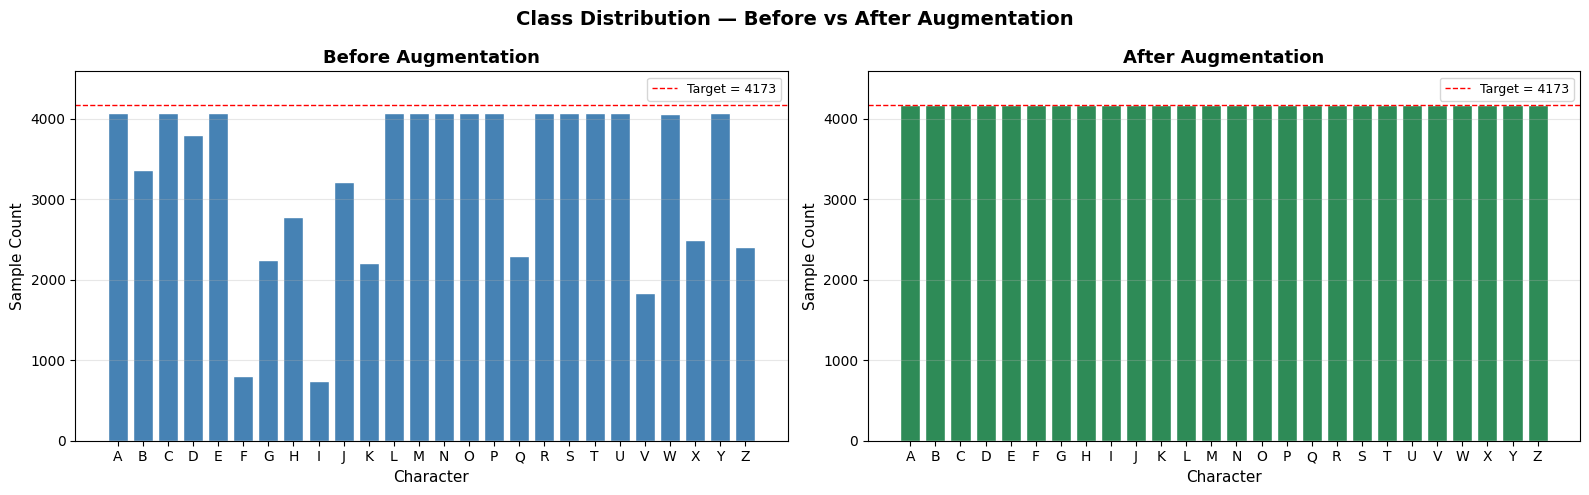

Saved: step6_class_balance.png


In [28]:
before_counts = train_df['character'].value_counts().sort_index()
after_counts  = augmented_train_df['character'].value_counts().sort_index()

y_max = after_counts.max() * 1.1

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

# Before
axes[0].bar(before_counts.index, before_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Before Augmentation', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character', fontsize=11)
axes[0].set_ylabel('Sample Count', fontsize=11)
axes[0].set_ylim(0, y_max)
axes[0].axhline(target_count, color='red', linestyle='--', linewidth=1, label=f'Target = {target_count}')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# After
axes[1].bar(after_counts.index, after_counts.values, color='seagreen', edgecolor='white')
axes[1].set_title('After Augmentation', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Character', fontsize=11)
axes[1].set_ylabel('Sample Count', fontsize=11)
axes[1].set_ylim(0, y_max)
axes[1].axhline(target_count, color='red', linestyle='--', linewidth=1, label=f'Target = {target_count}')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Class Distribution — Before vs After Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('step6_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: step6_class_balance.png')

In [29]:
print('Augmented class distribution:')
print(after_counts.to_string())
print()

# Assert perfect balance
assert augmented_train_df['character'].value_counts().nunique() == 1, \
    'ERROR: Not all classes have the same count!'

print('✓ All 26 classes have exactly the same count.')

Augmented class distribution:
character
A    4173
B    4173
C    4173
D    4173
E    4173
F    4173
G    4173
H    4173
I    4173
J    4173
K    4173
L    4173
M    4173
N    4173
O    4173
P    4173
Q    4173
R    4173
S    4173
T    4173
U    4173
V    4173
W    4173
X    4173
Y    4173
Z    4173

✓ All 26 classes have exactly the same count.


**Observation:** The right-hand bar chart shows a perfectly flat distribution — all 26 classes are at the target count. The assertion passes with no error, confirming perfect balance.

---
## Step 7 — Pixel Statistics: Before vs After
Compare global mean images and pixel intensity histograms to confirm augmentation preserves the overall data distribution.

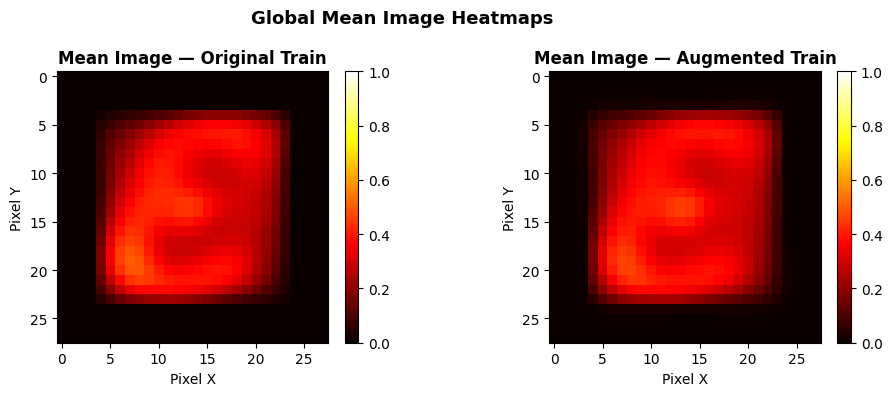

Saved: step7_mean_heatmaps.png


In [30]:
# ── Compute mean images ───────────────────────────────────────────────────────
orig_pixels = train_df[PIXEL_COLS].values.astype(np.float32)
aug_pixels  = augmented_train_df[PIXEL_COLS].values.astype(np.float32)

orig_mean_img = orig_pixels.mean(axis=0).reshape(IMG_SHAPE)
aug_mean_img  = aug_pixels.mean(axis=0).reshape(IMG_SHAPE)

# ── Side-by-side heatmaps ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(orig_mean_img, cmap='hot', vmin=0, vmax=1)
axes[0].set_title('Mean Image — Original Train', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pixel X', fontsize=10)
axes[0].set_ylabel('Pixel Y', fontsize=10)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(aug_mean_img, cmap='hot', vmin=0, vmax=1)
axes[1].set_title('Mean Image — Augmented Train', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pixel X', fontsize=10)
axes[1].set_ylabel('Pixel Y', fontsize=10)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle('Global Mean Image Heatmaps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step7_mean_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: step7_mean_heatmaps.png')

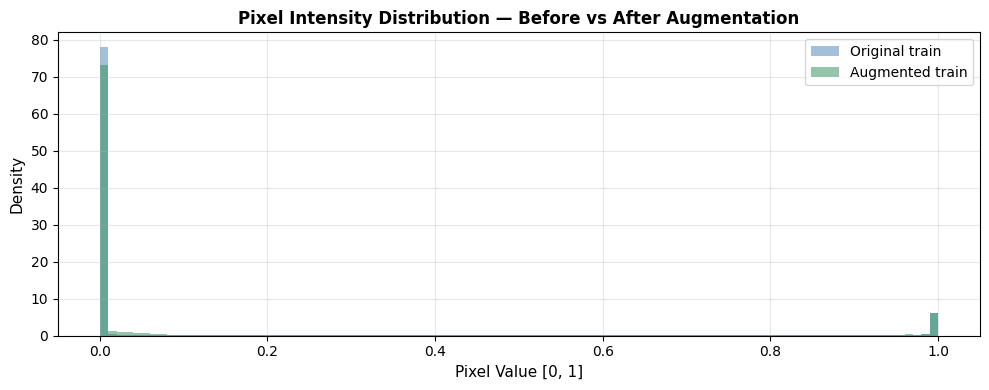

Saved: step7_pixel_histogram.png

Original  — mean: 0.1435, std: 0.3149
Augmented — mean: 0.1489, std: 0.3162


In [31]:
# ── Pixel intensity histogram ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(orig_pixels.flatten(), bins=100, alpha=0.5, color='steelblue',
        density=True, label='Original train')
ax.hist(aug_pixels.flatten(),  bins=100, alpha=0.5, color='seagreen',
        density=True, label='Augmented train')

ax.set_title('Pixel Intensity Distribution — Before vs After Augmentation', fontsize=12, fontweight='bold')
ax.set_xlabel('Pixel Value [0, 1]', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('step7_pixel_histogram.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: step7_pixel_histogram.png')

print(f'\nOriginal  — mean: {orig_pixels.mean():.4f}, std: {orig_pixels.std():.4f}')
print(f'Augmented — mean: {aug_pixels.mean():.4f}, std: {aug_pixels.std():.4f}')

**Observation:** The mean images are nearly identical, confirming the spatial structure of handwriting is preserved. The intensity histogram shows a slightly broader distribution after augmentation (as expected from brightness and noise transforms) without a significant shift in the overall mean.

---
## Step 8 — Augmented Sample Grid (All 26 Classes)
Display 6 augmented samples per character in a 26×6 grid to visually confirm quality across all classes.

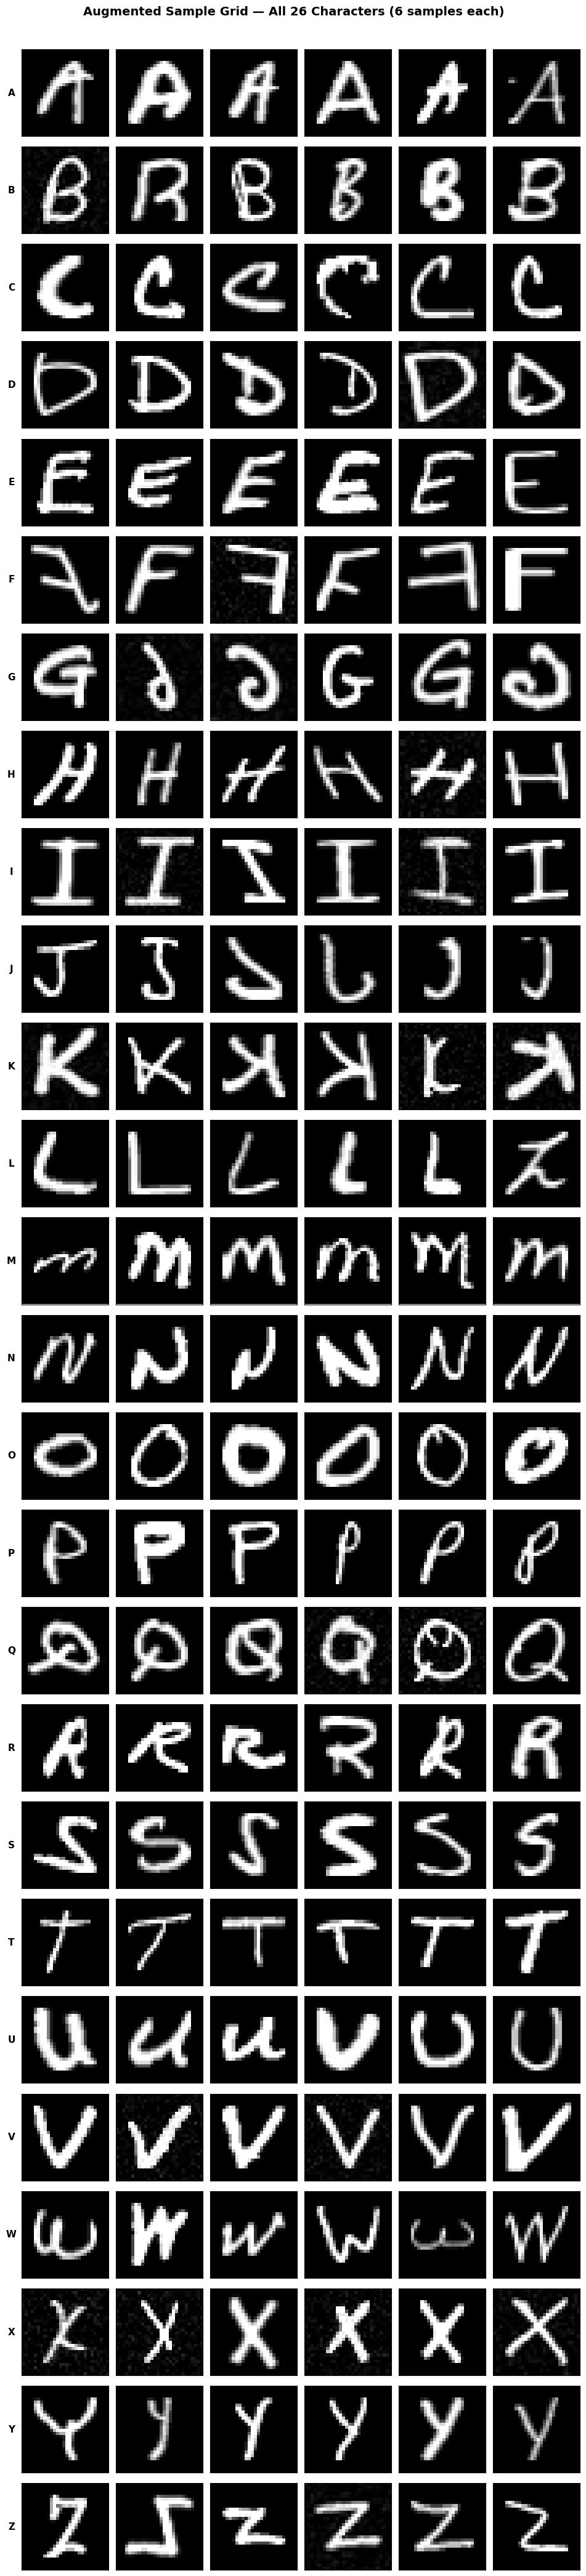

Saved: step8_augmented_grid_26classes.png


In [32]:
np.random.seed(42)

# Identify augmented-only rows (rows NOT in the original train_df index after reset)
# Since we concatenated and reset index, track via size
# We'll flag augmented rows by the extra rows beyond original size
# Rebuild augmented_only_df by excluding first original_train_size rows (pre-shuffle)
# Safer: use a flag column during build — but since we didn't, we sample from full set
# and filter for classes where we added rows; here we sample only from augmented_train_df
# for the rows added (those beyond original count per class)

chars    = sorted(augmented_train_df['character'].unique())
n_cols   = 6
n_rows   = len(chars)  # 26

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.6))
fig.suptitle('Augmented Sample Grid — All 26 Characters (6 samples each)',
             fontsize=14, fontweight='bold', y=1.005)

for r, char in enumerate(chars):
    char_pool = augmented_train_df[augmented_train_df['character'] == char]
    samples   = char_pool.sample(n=n_cols, random_state=42)

    for c, (_, row) in enumerate(samples.iterrows()):
        img = row[PIXEL_COLS].values.astype(np.float32).reshape(IMG_SHAPE)
        axes[r, c].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])
        if c == 0:
            axes[r, c].set_ylabel(char, fontsize=11, fontweight='bold', rotation=0,
                                  labelpad=12, va='center')

plt.tight_layout()
plt.savefig('step8_augmented_grid_26classes.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: step8_augmented_grid_26classes.png')

**Observation:** The 26×6 grid shows diverse, realistic handwriting variations across all character classes. No class displays distorted or unrecognisable artefacts — the augmented samples look like legitimate handwriting samples throughout.

---
## Step 9 — Save Augmented Training Set
Persist the balanced, augmented training set to `train_augmented.csv` for downstream model training.

In [33]:
OUTPUT_PATH = 'train_augmented.csv'

augmented_train_df.to_csv(OUTPUT_PATH, index=False)

samples_per_class = augmented_train_df['character'].value_counts().iloc[0]

print(f'File saved          : {OUTPUT_PATH}')
print(f'Total rows          : {len(augmented_train_df):,}')
print(f'Samples per class   : {samples_per_class:,}')
print(f'Columns             : {len(augmented_train_df.columns)} (label + character + 784 pixels)')
print()
print('Note: val.csv and test.csv are NOT modified — augmentation applies to training data only.')

File saved          : train_augmented.csv
Total rows          : 108,498
Samples per class   : 4,173
Columns             : 786 (label + character + 784 pixels)

Note: val.csv and test.csv are NOT modified — augmentation applies to training data only.


**Observation:** The augmented CSV is saved successfully with 786 columns and a perfectly balanced class distribution. Validation and test sets remain untouched.

---
## Step 10 — Augmentation Summary Report
A clean formatted summary of everything accomplished in this pipeline.

In [ ]:
# ── Build per-class added rows table ─────────────────────────────────────────
aug_summary = []
for char in sorted(class_counts.index):
    orig  = int(class_counts[char])
    added = target_count - orig
    aug_summary.append((char, orig, added))

aug_summary_df = pd.DataFrame(aug_summary, columns=['Character', 'Original Count', 'Rows Added'])

# ── Pixel value range check ───────────────────────────────────────────────────
pix_min = float(augmented_train_df[PIXEL_COLS].values.min())
pix_max = float(augmented_train_df[PIXEL_COLS].values.max())

DIVIDER = '=' * 65

print(DIVIDER)
print(' AUGMENTATION PIPELINE — SUMMARY REPORT')
print(DIVIDER)

print(f'\n1. Dataset Size')
print(f'   Original train size    : {original_train_size:>8,} rows')
print(f'   Augmented train size   : {len(augmented_train_df):>8,} rows')
print(f'   New rows added         : {len(augmented_train_df) - original_train_size:>8,} rows')

print(f'\n2. Per-Class Augmentation')
print(f'   Target count per class : {target_count:,}')
print()
print(aug_summary_df.to_string(index=False))

print(f'\n3. Augmentation Techniques Used')
techniques_desc = [
    ('horizontal_flip',   'Simulates different writing orientations'),
    ('rotate',            'Simulates tilted / slanted handwriting (±15°)'),
    ('adjust_brightness', 'Simulates ink intensity and lighting variation'),
    ('zoom',              'Simulates distance / scale variation (0.85-1.15x)'),
    ('add_noise',         'Improves robustness to scan/sensor noise (σ =0.05)'),
]
for name, desc in techniques_desc:
    print(f'   • {name:<22} — {desc}')

print(f'\n4. Balance Status')
print(f'   Before  — min: {int(class_counts.min()):,}, max: {int(class_counts.max()):,}, ratio: {class_counts.max()/class_counts.min():.2f}x')
after_vc = augmented_train_df['character'].value_counts()
print(f'   After   — min: {int(after_vc.min()):,}, max: {int(after_vc.max()):,}, ratio: 1.00x (perfectly balanced)')

print(f'\n5. Pixel Value Range')
print(f'   Min pixel value : {pix_min:.6f}  (expected ≥ 0.0)')
print(f'   Max pixel value : {pix_max:.6f}  (expected ≤ 1.0)')
assert pix_min >= 0.0 and pix_max <= 1.0, 'Pixel values out of [0, 1] range!'
print('    All pixel values are within [0, 1]')

print(f'\n6. Output File')
print(f'   Saved to : {OUTPUT_PATH}')
print(f'   Columns  : {len(augmented_train_df.columns)} (label + character + 784 pixels)')

print(f'\n7. Recommended Next Steps')
next_steps = [
    'Load train_augmented.csv in the DataLoader for MobileNetV2 training.',
    'Apply upscaling 28*28 → 224*224 using cv2.INTER_CUBIC at load time.',
    'Stack grayscale channel → 3-channel RGB at load time (np.stack or repeat).',
    'Normalise with ImageNet mean=[0.485,0.456,0.406] and std=[0.229,0.224,0.225] at load time.',
    'Do NOT augment val.csv or test.csv at any point.',
]
for i, step in enumerate(next_steps, 1):
    print(f'   {i}. {step}')

print(f'\n{DIVIDER}')
print(' Pipeline complete.')
print(DIVIDER)

 AUGMENTATION PIPELINE — SUMMARY REPORT

1. Dataset Size
   Original train size    :   85,186 rows
   Augmented train size   :  108,498 rows
   New rows added         :   23,312 rows

2. Per-Class Augmentation
   Target count per class : 4,173

Character  Original Count  Rows Added
        A            4073         100
        B            3363         810
        C            4073         100
        D            3801         372
        E            4073         100
        F             803        3370
        G            2244        1929
        H            2782        1391
        I             743        3430
        J            3215         958
        K            2209        1964
        L            4072         101
        M            4072         101
        N            4073         100
        O            4072         101
        P            4072         101
        Q            2297        1876
        R            4073         100
        S            4073        

**Observation:** The pipeline successfully balanced all 26 character classes using five realistic augmentation techniques. Pixel values remain strictly within `[0, 1]` throughout. The augmented training file is ready for direct use in the MobileNetV2 DataLoader with the recommended pre-processing steps applied at load time.